# Part 2: RLHF on a Language Model
## DRL Assignment, Spring 2026 — Tilburg University

In this part of the assignment, you will fine-tune a small language model (GPT-2) using **Reinforcement Learning from Human Feedback (RLHF)**. This is the same technique used to train ChatGPT, Claude, and other modern AI assistants.

### The task

We start with a GPT-2 model that has been fine-tuned on IMDb movie reviews (it generates movie review text — both positive and negative). We then use **PPO** (Proximal Policy Optimization) to further fine-tune the model so that it generates **positive** movie reviews, using a sentiment classifier as a reward signal.

The key RLHF components:
- **Policy model**: GPT-2 (the model being fine-tuned)
- **Reference model**: A frozen copy of the initial GPT-2 (used for KL penalty)
- **Reward model**: A pre-trained sentiment classifier (returns high scores for positive text)
- **KL penalty**: Keeps the policy close to the reference model, preventing degenerate outputs

### Important notes
- This notebook is designed to run on **Google Colab with a T4 GPU**. Training takes approximately 30-60 minutes.
- If running on Colab, make sure to select a GPU runtime: Runtime → Change runtime type → T4 GPU.
- We use a **pinned version** of the TRL library (`trl==0.9.6`) for its manual training loop, which is pedagogically clearer.

### Reference
This notebook is based on the TRL library's sentiment fine-tuning example by Leandro von Werra et al. See: https://github.com/huggingface/trl and the TRL documentation at https://huggingface.co/docs/trl/.

---
## 0. Setup

In [1]:
# Install required packages (run this cell first!)
# !pip install trl==0.9.6 transformers==4.46.3 datasets accelerate torch
# !pip install matplotlib numpy

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import warnings
import logging

from transformers import AutoTokenizer, pipeline
from datasets import load_dataset
from trl import PPOTrainer, PPOConfig, AutoModelForCausalLMWithValueHead
from trl.core import LengthSampler

# Suppress repetitive warnings from transformers (attention mask, pad token)
warnings.filterwarnings("ignore", message=".*attention mask.*")
warnings.filterwarnings("ignore", message=".*pad_token_id.*")
logging.getLogger("transformers").setLevel(logging.ERROR)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


import json
import pickle
from pathlib import Path

RESULTS_DIR = Path("rlhf_results")
RESULTS_DIR.mkdir(exist_ok=True)

/home/u890345/.conda/envs/drl_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


/home/u890345/.conda/envs/drl_env/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


---
## 1. Configuration

We configure the PPO trainer below. The key parameter you will experiment with is `init_kl_coef` — the coefficient for the KL penalty that prevents the model from drifting too far from the reference model.

We set `adap_kl_ctrl=False` so that the KL coefficient remains **fixed** throughout training (rather than adapting automatically). This allows us to study its effect directly.

In [3]:
# --- Configuration ---
MODEL_NAME = "lvwerra/gpt2-imdb"  # GPT-2 already fine-tuned on IMDb reviews
SENTIMENT_MODEL = "lvwerra/distilbert-imdb"  # Pre-trained sentiment classifier

KL_COEF = 0.2  # <-- You will sweep this parameter in Task 2b

ppo_config = PPOConfig(
    model_name=MODEL_NAME,
    learning_rate=1.41e-5,
    batch_size=64,
    mini_batch_size=16,
    ppo_epochs=2,
    init_kl_coef=KL_COEF,       # KL penalty coefficient
    adap_kl_ctrl=False,          # Fixed KL coefficient (no adaptive control)
    kl_penalty="kl",
    cliprange=0.2,
    gamma=1.0,
    lam=0.95,
    log_with=None,               # Set to "tensorboard" or "wandb" if desired
)

# Generation settings
GEN_KWARGS = {
    "top_k": 0,
    "top_p": 1.0,
    "do_sample": True,
}

# Number of PPO training steps (each step processes one batch)
N_TRAIN_STEPS = 100

print(f"KL coefficient: {KL_COEF}")
print(f"Batch size: {ppo_config.batch_size}")
print(f"Training steps: {N_TRAIN_STEPS}")

KL coefficient: 0.2
Batch size: 64
Training steps: 100


---
## 2. Load models and data

In [4]:
# Load the IMDb dataset (we only need the text for query prompts)
dataset = load_dataset("imdb", split="train")

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

# Prepare dataset: tokenize the first few tokens of each review as "query" prompts
def tokenize(example):
    tokens = tokenizer.encode(example["text"], truncation=True, max_length=128)
    # Use the first 5-10 tokens as the query prompt
    query_length = random.randint(5, 10)
    example["input_ids"] = tokens[:query_length]
    example["query"] = tokenizer.decode(example["input_ids"])
    return example

dataset = dataset.map(tokenize, batched=False)
dataset.set_format(type="torch")

# Helper collator
def collator(data):
    return dict((key, [d[key] for d in data]) for key in data[0])

print(f"Dataset size: {len(dataset)}")
print(f"Example query: '{dataset[0]['query']}'")

Dataset size: 25000
Example query: 'I rented I AM CURIOUS-Y'


In [5]:
# Load the policy model (GPT-2 with a value head for PPO)
model = AutoModelForCausalLMWithValueHead.from_pretrained(MODEL_NAME).to(device)

# Load the reference model (frozen copy — used for KL computation)
ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(MODEL_NAME).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model device: {next(model.parameters()).device}")

Model parameters: 124,440,577
Model device: cpu


In [6]:
# Load the sentiment classifier (our "reward model")
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    device=device,
    truncation=True,
    max_length=512,
)

# Quick test
test_texts = [
    "This movie was absolutely fantastic! A masterpiece.",
    "Terrible film. Waste of time and money.",
]
for text, result in zip(test_texts, sentiment_pipe(test_texts)):
    print(f"  '{text[:50]}...' => {result['label']}: {result['score']:.3f}")

  'This movie was absolutely fantastic! A masterpiece...' => POSITIVE: 0.996
  'Terrible film. Waste of time and money....' => NEGATIVE: 0.997


---
## 3. Generate "before" samples

Before RLHF training, let's see what the model generates. Since it was fine-tuned on all IMDb reviews (positive and negative), we expect a mix of sentiments.

In [7]:
def generate_samples(model, tokenizer, prompts, max_new_tokens=60, n_samples=8):
    """Generate text samples from the model and score them with the sentiment classifier."""
    model.eval()
    samples = []
    for prompt in prompts[:n_samples]:
        input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model.generate(
                input_ids,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_p=1.0,
                top_k=0,
                pad_token_id=tokenizer.eos_token_id,
            )
        text = tokenizer.decode(output[0], skip_special_tokens=True)
        sentiment = sentiment_pipe([text])[0]
        samples.append((prompt, text, sentiment))
    return samples


def print_samples(samples, title="Generated samples"):
    print(f"\n{'='*70}")
    print(f" {title}")
    print(f"{'='*70}")
    for i, (prompt, text, sentiment) in enumerate(samples):
        score = sentiment['score'] if sentiment['label'] == 'POSITIVE' else 1 - sentiment['score']
        print(f"\n--- Sample {i+1} (sentiment: {score:.3f}) ---")
        print(f"Prompt: '{prompt}'")
        print(f"Output: {text[:200]}")


# Sample prompts
sample_prompts = [
    "This movie",
    "I watched this",
    "The acting in",
    "A wonderful",
    "The plot was",
    "I really",
    "One of the",
    "The director",
]

before_samples = generate_samples(model, tokenizer, sample_prompts)
print_samples(before_samples, title="BEFORE RLHF")


 BEFORE RLHF

--- Sample 1 (sentiment: 0.007) ---
Prompt: 'This movie'
Output: This movie has all the Hollywood and American Westerns, but in the East all effervescent and messy decay. That schmaltz sandwich looks so offensive that 90 minutes later I'd say "You would not think s

--- Sample 2 (sentiment: 0.778) ---
Prompt: 'I watched this'
Output: I watched this film and i thought it was just a great show. However at some point i came to where the computer prepared some dummy (spray gun), it basically turned it into a gun, that is what i think.

--- Sample 3 (sentiment: 0.945) ---
Prompt: 'The acting in'
Output: The acting in parts was decent, there was pretty much nothing really happening throughout the movie. The only comic relief I could watch was something basically called "Batman". I've read that actual 

--- Sample 4 (sentiment: 0.990) ---
Prompt: 'A wonderful'
Output: A wonderful film: If you are interested in science fiction movies, then follow their lead'n it<br /><br />Take 

---
## 4. Set up the PPO Trainer

In [8]:
# Create the PPO Trainer
ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=model,
    ref_model=ref_model,
    tokenizer=tokenizer,
    dataset=dataset,
    data_collator=collator,
)

# Sampler for controlling generation length (between 20 and 60 new tokens)
output_length_sampler = LengthSampler(20, 60)

print("PPO Trainer ready.")

PPO Trainer ready.


---
## 5. Reward function

Our goal is to bias the model toward generating **positive** movie reviews, rather than the mix of positive and negative reviews it currently produces. To do this, we use the sentiment classifier as a **reward signal**: each time the model generates a piece of text, we score it with the classifier and use the probability of positive sentiment as the reward.

Concretely, the reward for a generated text is simply the classifier's estimated probability that the text is positive:
- If the classifier returns label `"POSITIVE"` with score 0.92, the reward is **0.92**
- If the classifier returns label `"NEGATIVE"` with score 0.85, the positive probability is 1 − 0.85 = 0.15, so the reward is **0.15**

By rewarding positive sentiment, PPO will update the model's parameters to make it more likely to generate text that the classifier considers positive.

In [9]:
# Sentiment pipeline kwargs
sent_kwargs = {"return_all_scores": False, "truncation": True, "max_length": 512}


def compute_rewards(texts):
    """Compute sentiment rewards for a list of generated texts.

    Args:
        texts: list of strings (the generated movie reviews)

    Returns:
        rewards: list of torch.FloatTensor scalars, one per text.
                 Each reward is the probability that the text is positive
                 (a value between 0 and 1).
    """
    pipe_outputs = sentiment_pipe(texts, **sent_kwargs)
    rewards = []
    for output in pipe_outputs:
        if output["label"] == "POSITIVE":
            rewards.append(torch.tensor(output["score"]))
        else:
            rewards.append(torch.tensor(1.0 - output["score"]))
    return rewards


# Quick test
test_rewards = compute_rewards(["This was a great movie!", "Terrible, awful film."])
print(f"Rewards: {[f'{r.item():.3f}' for r in test_rewards]}")
# Expected: roughly [~0.9+, ~0.1-]

Rewards: ['0.995', '0.004']


/home/u890345/.conda/envs/drl_env/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


---
## 6. Training loop

This is the core RLHF loop. For each batch:
1. **Generate** responses to query prompts using the current policy
2. **Score** the responses with the sentiment classifier (reward model)
3. **PPO step**: update the policy to maximize rewards while staying close to the reference model (via KL penalty)

We log the mean reward, mean KL divergence, and sample generated texts.

In [10]:
section6_log_file = RESULTS_DIR / f"06_training_logs_kl{KL_COEF}.pkl"
model_save_dir = RESULTS_DIR / f"06_trained_model_kl{KL_COEF}"

if section6_log_file.exists() and model_save_dir.exists():
    print(f"Section 6 already done for KL={KL_COEF}, loading logs and trained model.")

    with open(section6_log_file, "rb") as f:
        training_logs = pickle.load(f)

    all_mean_rewards = training_logs["mean_rewards"]
    all_mean_kl = training_logs["mean_kl"]
    sample_texts_during_training = training_logs["sample_texts_during_training"]

    model = AutoModelForCausalLMWithValueHead.from_pretrained(str(model_save_dir)).to(device)
    tokenizer = AutoTokenizer.from_pretrained(str(model_save_dir))
    tokenizer.pad_token = tokenizer.eos_token

else:
    # Storage for logging
    all_mean_rewards = []
    all_mean_kl = []
    sample_texts_during_training = []  # snapshots of generated text at intervals

    print(f"Starting PPO training for {N_TRAIN_STEPS} steps...")
    print(f"KL coefficient: {KL_COEF}")
    print()

    for step, batch in enumerate(tqdm(ppo_trainer.dataloader, total=N_TRAIN_STEPS)):
        if step >= N_TRAIN_STEPS:
            break

        query_tensors = batch["input_ids"]

        # --- Step 1: Generate responses ---
        response_tensors = []
        for query in query_tensors:
            gen_len = output_length_sampler()
            gen_kwargs = {**GEN_KWARGS, "max_new_tokens": gen_len}
            response = ppo_trainer.generate(query, **gen_kwargs)
            response_tensors.append(response.squeeze()[-gen_len:])

        # Decode query + response to text
        batch["response"] = [tokenizer.decode(r.squeeze()) for r in response_tensors]
        texts = [q + r for q, r in zip(batch["query"], batch["response"])]

        # --- Step 2: Compute rewards ---
        rewards = compute_rewards(texts)

        # --- Step 3: PPO update ---
        stats = ppo_trainer.step(query_tensors, response_tensors, rewards)

        # --- Logging ---
        mean_reward = np.mean([r.item() for r in rewards])
        mean_kl = stats["ppo/mean_kl_coef"] if "ppo/mean_kl_coef" in stats else stats.get("objective/kl", 0)
        all_mean_rewards.append(mean_reward)
        all_mean_kl.append(mean_kl)

        # Save text samples periodically
        if step % 50 == 0 or step == N_TRAIN_STEPS - 1:
            sample_texts_during_training.append({
                "step": step,
                "texts": texts[:3],
                "rewards": [r.item() for r in rewards[:3]],
            })

        if step % 20 == 0:
            print(f"Step {step} | Mean reward: {mean_reward:.3f} | Mean KL: {mean_kl:.4f}")

    print("\nTraining complete!")

    # Save the model cause first time I ran out of time on cluster
    model.save_pretrained(model_save_dir)
    tokenizer.save_pretrained(model_save_dir)

    print(f"Saved trained model to {model_save_dir}")

    training_logs = {
        "kl_coef": KL_COEF,
        "n_train_steps": N_TRAIN_STEPS,
        "mean_rewards": all_mean_rewards,
        "mean_kl": all_mean_kl,
        "sample_texts_during_training": sample_texts_during_training,
    }

    with open(section6_log_file, "wb") as f:
        pickle.dump(training_logs, f)

    print(f"Saved training logs to {section6_log_file}")

Section 6 already done for KL=0.2, loading logs and trained model.


---
## 7. Generate "after" samples and compare

In [11]:
after_samples = generate_samples(model, tokenizer, sample_prompts)
print_samples(after_samples, title="AFTER RLHF")

# Compare before vs after sentiment scores
before_scores = [s['score'] if s['label'] == 'POSITIVE' else 1-s['score'] for _, _, s in before_samples]
after_scores = [s['score'] if s['label'] == 'POSITIVE' else 1-s['score'] for _, _, s in after_samples]

print(f"\nMean positive sentiment — Before: {np.mean(before_scores):.3f}, After: {np.mean(after_scores):.3f}")


 AFTER RLHF

--- Sample 1 (sentiment: 0.993) ---
Prompt: 'This movie'
Output: This movie was exciting! A side note: Joe Franco teaches Iraffa about romance and humanity. The intelligence is great and the cast (kids, black men, male comedy) makes you think about the things that 

--- Sample 2 (sentiment: 0.968) ---
Prompt: 'I watched this'
Output: I watched this movie with a friend who didn't have a fan. He says that when this movie came out, I could see bigger things when I saw it. "Bzzz!" I loved such a movie, so I get all the "things." There

--- Sample 3 (sentiment: 0.939) ---
Prompt: 'The acting in'
Output: The acting in this movie proves that Itiko is a decent actress, mechanical thany, smart but funny and wants to be her own boss. Dialogue wise he is really good as overpowering Mexican and Emerald (he 

--- Sample 4 (sentiment: 0.995) ---
Prompt: 'A wonderful'
Output: A wonderful film, undiminished by the material it is made for and I especially liked the premise.

--- Sample 5 

In [12]:
section7_outputs = {
    "kl_coef": KL_COEF,
    "before_samples": before_samples,
    "after_samples": after_samples,
    "before_scores": before_scores,
    "after_scores": after_scores,
    "before_mean_positive": np.mean(before_scores),
    "after_mean_positive": np.mean(after_scores),
}

FILE_NAME = RESULTS_DIR / f"07_before_after_samples_kl{KL_COEF}.pkl"

with open(FILE_NAME, "wb") as f:
    pickle.dump(section7_outputs, f)

print(f"Saved Section 7 outputs to {FILE_NAME}")

Saved Section 7 outputs to rlhf_results/07_before_after_samples_kl0.2.pkl


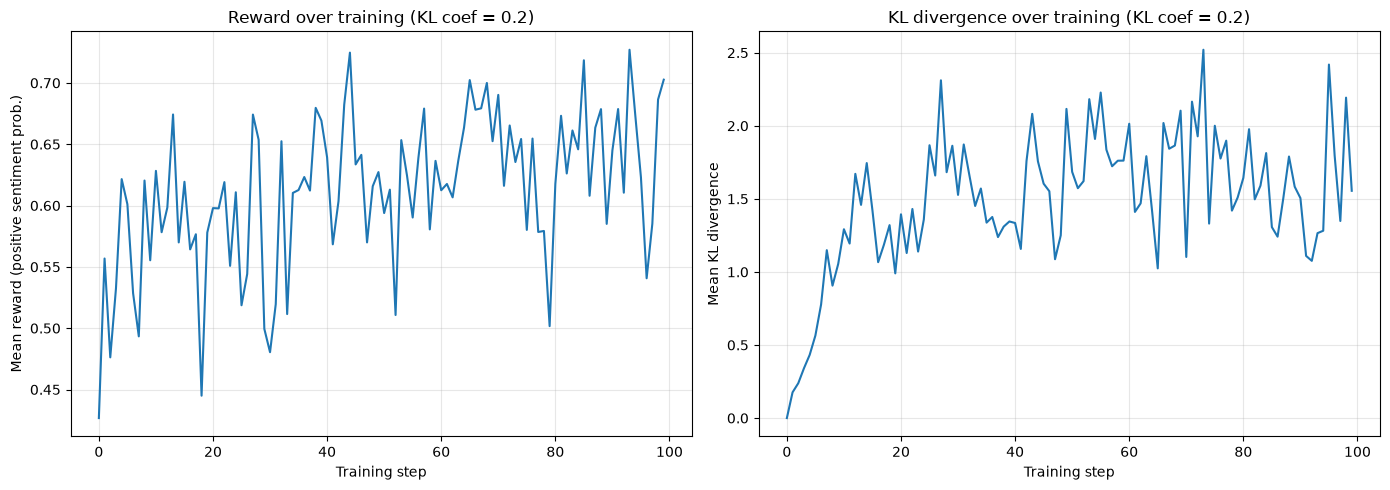

In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(all_mean_rewards)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Mean reward (positive sentiment prob.)")
axes[0].set_title(f"Reward over training (KL coef = {KL_COEF})")
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_mean_kl)
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Mean KL divergence")
axes[1].set_title(f"KL divergence over training (KL coef = {KL_COEF})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"07_training_curves_kl{KL_COEF}.png", dpi=150)
# plt.savefig(f"training_curves_kl{KL_COEF}.png", dpi=150)
plt.show()

---
## 8. KL coefficient sweep (Task 2b)

**TODO:** Run the entire training pipeline above for multiple values of the KL coefficient. For each value:
1. Record the reward curve over training steps
2. Record the KL divergence curve over training steps
3. Save generated text samples at the end of training
4. Note the final mean reward and final mean KL divergence

Suggested KL coefficients to try: `[0.0, 0.01, 0.05, 0.2, 1.0]`

**Hint:** You can wrap the training code from sections 2-7 into a function and call it in a loop. We provide a skeleton below.

**Important:** Each run requires re-initializing the model from scratch (otherwise you'd be continuing from the previous run's trained model). Make sure you reload `model` and `ref_model` for each KL coefficient.

In [14]:
def run_rlhf_experiment(kl_coef, n_steps=200):
    """Run one full RLHF experiment with a given KL coefficient.

    Returns a dict with reward curve, KL curve, and generated samples.
    """
    print(f"\n{'='*60}")
    print(f"  Running experiment with KL coefficient = {kl_coef}")
    print(f"{'='*60}\n")

    # Fresh models for each experiment
    exp_model = AutoModelForCausalLMWithValueHead.from_pretrained(MODEL_NAME).to(device)
    exp_ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(MODEL_NAME).to(device)

    # Config with this KL coefficient
    exp_config = PPOConfig(
        model_name=MODEL_NAME,
        learning_rate=1.41e-5,
        batch_size=64,
        mini_batch_size=16,
        ppo_epochs=4,
        init_kl_coef=kl_coef,
        adap_kl_ctrl=False,
        kl_penalty="kl",
        cliprange=0.2,
        gamma=1.0,
        lam=0.95,
        log_with=None,
    )

    exp_trainer = PPOTrainer(
        config=exp_config,
        model=exp_model,
        ref_model=exp_ref_model,
        tokenizer=tokenizer,
        dataset=dataset,
        data_collator=collator,
    )

    exp_rewards = []
    exp_kl = []

    for step, batch in enumerate(tqdm(exp_trainer.dataloader, total=n_steps, desc=f"KL={kl_coef}")):
        if step >= n_steps:
            break

        query_tensors = batch["input_ids"]

        response_tensors = []
        for query in query_tensors:
            gen_len = output_length_sampler()
            gen_kwargs = {**GEN_KWARGS, "max_new_tokens": gen_len}
            response = exp_trainer.generate(query, **gen_kwargs)
            response_tensors.append(response.squeeze()[-gen_len:])

        batch["response"] = [tokenizer.decode(r.squeeze()) for r in response_tensors]
        texts = [q + r for q, r in zip(batch["query"], batch["response"])]

        rewards = compute_rewards(texts)
        stats = exp_trainer.step(query_tensors, response_tensors, rewards)

        exp_rewards.append(np.mean([r.item() for r in rewards]))
        kl_val = stats.get("objective/kl", 0)
        exp_kl.append(kl_val)

    # Generate final samples
    final_samples = generate_samples(exp_model, tokenizer, sample_prompts)

    # Clean up to free GPU memory
    del exp_trainer, exp_ref_model, exp_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return {
        "kl_coef": kl_coef,
        "rewards": exp_rewards,
        "kl_values": exp_kl,
        "final_samples": final_samples,
        "final_mean_reward": np.mean(exp_rewards[-20:]),
        "final_mean_kl": np.mean(exp_kl[-20:]) if exp_kl else 0,
    }

In [15]:
# TODO: Run experiments for different KL coefficients
# Uncomment and run once you have implemented compute_rewards above.

individual_results_dir = RESULTS_DIR / "08_individual_kl_results"
individual_results_dir.mkdir(exist_ok=True)

kl_coefs = [0.0, 0.01, 0.05, 0.2, 1.0]
results = {}
for kl in kl_coefs:
    file_name = individual_results_dir / f"kl{kl}.pkl"

    if file_name.exists():
        print(f"Loading existing result for KL={kl} from {file_name}")
        with open(file_name, "rb") as f:
            results[kl] = pickle.load(f)

    else:
        print(f"No existing result for KL={kl}; running experiment.")
        results[kl] = run_rlhf_experiment(kl, n_steps=200)

        with open(file_name, "wb") as f:
            pickle.dump(results[kl], f)

        print(f"Saved result for KL={kl} to {file_name}")

Loading existing result for KL=0.0 from rlhf_results/08_individual_kl_results/kl0.0.pkl
No existing result for KL=0.01; running experiment.

  Running experiment with KL coefficient = 0.01



KL=0.01:   0%|          | 0/200 [00:00<?, ?it/s]

KL=0.01:   0%|          | 1/200 [00:41<2:18:40, 41.81s/it]

KL=0.01:   1%|          | 2/200 [01:27<2:24:56, 43.92s/it]

KL=0.01:   2%|▏         | 3/200 [02:10<2:22:38, 43.45s/it]

...

KL=1.0:  99%|█████████▉| 198/200 [2:02:05<01:11, 35.97s/it]

KL=1.0: 100%|█████████▉| 199/200 [2:02:42<00:36, 36.08s/it]

KL=1.0: 100%|██████████| 200/200 [2:03:17<00:00, 35.99s/it]

KL=1.0: 100%|██████████| 200/200 [2:03:17<00:00, 36.99s/it]

Saved result for KL=1.0 to rlhf_results/08_individual_kl_results/kl1.0.pkl


---
## 9. Analysis

Use the cells below to analyze your results from the KL sweep.

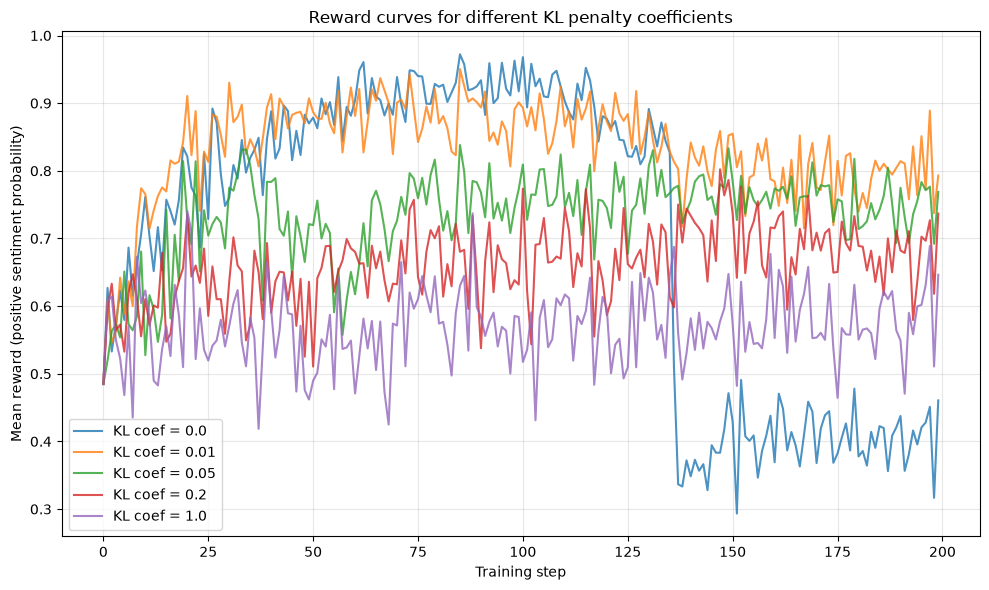

In [16]:
# TODO: Uncomment and run after completing the KL sweep

# --- Plot 1: Reward curves for all KL coefficients ---
plt.figure(figsize=(10, 6))
for kl, res in results.items():
    plt.plot(res["rewards"], label=f"KL coef = {kl}", alpha=0.8)
plt.xlabel("Training step")
plt.ylabel("Mean reward (positive sentiment probability)")
plt.title("Reward curves for different KL penalty coefficients")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("reward_curves_kl_sweep.png", dpi=150)
plt.savefig(RESULTS_DIR / "09_reward_curves_kl_sweep.png", dpi=150)
plt.show()

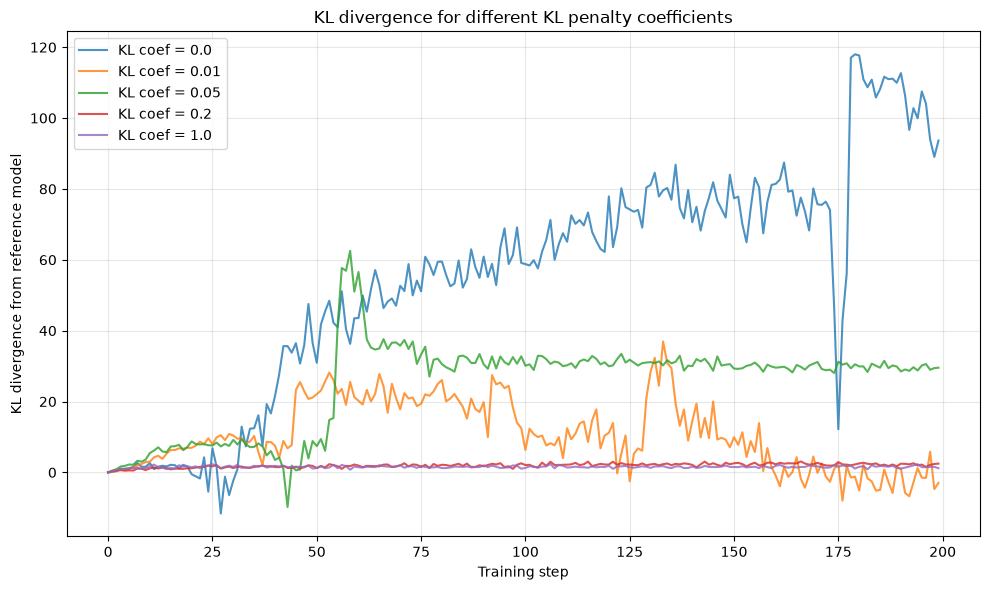

In [17]:
# --- Plot 2: KL divergence curves ---
plt.figure(figsize=(10, 6))
for kl, res in results.items():
    plt.plot(res["kl_values"], label=f"KL coef = {kl}", alpha=0.8)
plt.xlabel("Training step")
plt.ylabel("KL divergence from reference model")
plt.title("KL divergence for different KL penalty coefficients")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("kl_curves_sweep.png", dpi=150)
plt.savefig(RESULTS_DIR / "09_kl_curves_sweep.png", dpi=150)
plt.show()

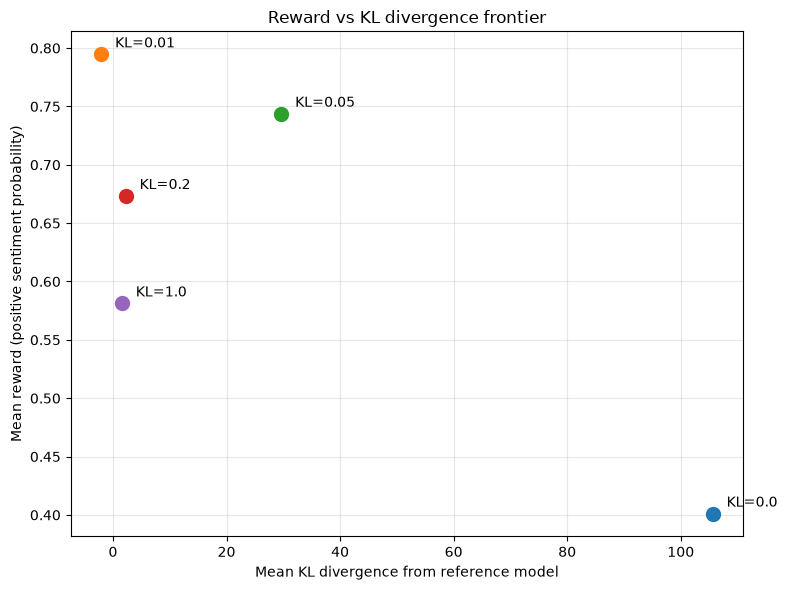

In [18]:
# # --- Plot 3: Reward vs KL frontier ---
# This is the key plot: it shows the tradeoff between reward and divergence.
plt.figure(figsize=(8, 6))
for kl, res in results.items():
    plt.scatter(res["final_mean_kl"], res["final_mean_reward"],
                s=100, zorder=5)
    plt.annotate(f"KL={kl}", (res["final_mean_kl"], res["final_mean_reward"]),
                 textcoords="offset points", xytext=(10, 5))
plt.xlabel("Mean KL divergence from reference model")
plt.ylabel("Mean reward (positive sentiment probability)")
plt.title("Reward vs KL divergence frontier")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("reward_kl_frontier.png", dpi=150)
plt.savefig(RESULTS_DIR / "09_reward_kl_frontier.png", dpi=150)
plt.show()

In [19]:
# --- Show generated text samples for each KL coefficient ---
for kl, res in results.items():
    print_samples(res["final_samples"], title=f"KL coefficient = {kl}")


 KL coefficient = 0.0

--- Sample 1 (sentiment: 0.460) ---
Prompt: 'This movie'
Output: This movie confronts prejudice through prejudice prejudice prejudiceness prejudiceness prejudiceness prejudiceness prejudiceness prejudiceness prejudiceness prejudicenessnessnessnessnessnessnessnessne

--- Sample 2 (sentiment: 0.709) ---
Prompt: 'I watched this'
Output: I watched this film yesterday for Dr. King's principles prejudice prejudice prejudiceness prejudiceness prejudiceness prejudiceness prejudicenessnessnessnessnessnessnessnessnessnessnessnessnessnessnes

--- Sample 3 (sentiment: 0.211) ---
Prompt: 'The acting in'
Output: The acting in the film reveals prejudice prejudice prejudice prejudiceness prejudiceness prejudiceness prejudiceness prejudiceness prejudiceness prejudicenessnessnessnessnessnessnessnessnessnessnessne

--- Sample 4 (sentiment: 0.991) ---
Prompt: 'A wonderful'
Output: A wonderful film shows prejudice prejudice prejudice prejudiceness prejudiceness prejudiceness prejudi

---
## 10. Discussion questions (to address in your report)

Based on your experiments, address the following in your report:

1. **Before vs. after RLHF:** How did the model's outputs change after training with the default KL coefficient? Show concrete examples.

2. **Effect of the KL coefficient:** How does the KL penalty coefficient affect the final reward, the divergence from the reference model, and the quality of generated text? Use your plots and text samples to support your analysis.

3. **Reward hacking:** For which KL coefficient(s) did you observe reward hacking — i.e., the model achieving high sentiment scores but producing low-quality or degenerate text? Show examples and explain why this happens.

4. **The reward-KL tradeoff:** Why is it impossible to achieve high reward AND low KL divergence simultaneously? What is the practical implication for real-world RLHF systems (e.g., ChatGPT, Claude)?